# Análise de Dados com Python

### Desafio:

Você trabalha em uma empresa do varejo e tem milhares de clientes diferentes.

Com o objetivo de aumentar o faturamento e o lucro da sua empresa, a diretoria quer conseguir identificar quem é o cliente ideal para seus produtos, baseado no histórico de compras dos clientes.

Para isso, ela fez um trabalho de classificar os clientes com uma nota de 1 a 100. Só que agora, sobrou para você conseguir, a partir dessa nota, descobrir qual o perfil de cliente ideal da empresa.

Qual a profissão? Qual a idade? Qual a faixa de renda? E todas as informações que você puder analisar para dizer qual o cliente ideal da empresa.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('..')
from functions import funcoes

In [2]:
df_clientes = pd.read_csv(r'../data/clientes.csv',sep=';',encoding='utf-8') 


# USEI O ENCODING LATIN1 POIS O UTF-8 DEU UM PROBLEMA NA LEITURA DA BASE DE DADOS.
# DA MESMA FORMA UTILIZEI O SEPARADOR SENDO (;) POIS A BASE ESTAVA BAGUNÇADA

### PADRONIZAÇÃO DE DADOS CATEGÓRICOS

In [3]:
display(df_clientes)

,ClienteID,Origem,Idade,Salario Anual (R$),Nota (1-100),Profissao,Experiencia Trabalho,Tamanho Familia,Unnamed: 8
0,1,Normal,19,15000,39,Sa�de,1,4,NaN
1,2,Normal,21,35000,81,Engenheiro,3,3,NaN
2,3,Promo��o,20,86000,2,Engenheiro,1,1,NaN
3,4,Promo��o,23,59000,73,Advogado,0,2,.
4,5,Promo��o,31,38000,48,Entretenimento,2,6,NaN
...,...,...,...,...,...,...,...,...,...
1995,1996,Promo��o,71,184387,48,Artista,8,7,NaN
1996,1997,Promo��o,91,73158,28,Doutor,7,7,NaN
1997,1998,Normal,87,90961,14,Sa�de,9,2,NaN
1998,1999,Normal,77,182109,4,Executivo,7,2,NaN


In [4]:
funcoes.corrigir_coluna(df=df_clientes,
                        coluna='Origem',
                        palavra_anomalica='Promo��o',
                        correcao='Promocao')

funcoes.corrigir_coluna(df=df_clientes,
                        coluna='Profissao',
                        palavra_anomalica='Constru��o',
                        correcao='Construcao')

funcoes.corrigir_coluna(df=df_clientes,
                        coluna='Profissao',
                        palavra_anomalica='Sa�de',
                        correcao='Saude')

,ClienteID,Origem,Idade,Salario Anual (R$),Nota (1-100),Profissao,Experiencia Trabalho,Tamanho Familia,Unnamed: 8
0,1,Normal,19,15000,39,Saude,1,4,NaN
1,2,Normal,21,35000,81,Engenheiro,3,3,NaN
2,3,Promocao,20,86000,2,Engenheiro,1,1,NaN
3,4,Promocao,23,59000,73,Advogado,0,2,.
4,5,Promocao,31,38000,48,Entretenimento,2,6,NaN
...,...,...,...,...,...,...,...,...,...
1995,1996,Promocao,71,184387,48,Artista,8,7,NaN
1996,1997,Promocao,91,73158,28,Doutor,7,7,NaN
1997,1998,Normal,87,90961,14,Saude,9,2,NaN
1998,1999,Normal,77,182109,4,Executivo,7,2,NaN


In [5]:
display(df_clientes)

,ClienteID,Origem,Idade,Salario Anual (R$),Nota (1-100),Profissao,Experiencia Trabalho,Tamanho Familia,Unnamed: 8
0,1,Normal,19,15000,39,Saude,1,4,NaN
1,2,Normal,21,35000,81,Engenheiro,3,3,NaN
2,3,Promocao,20,86000,2,Engenheiro,1,1,NaN
3,4,Promocao,23,59000,73,Advogado,0,2,.
4,5,Promocao,31,38000,48,Entretenimento,2,6,NaN
...,...,...,...,...,...,...,...,...,...
1995,1996,Promocao,71,184387,48,Artista,8,7,NaN
1996,1997,Promocao,91,73158,28,Doutor,7,7,NaN
1997,1998,Normal,87,90961,14,Saude,9,2,NaN
1998,1999,Normal,77,182109,4,Executivo,7,2,NaN


### TRATAMENTO DOS DADOS

In [6]:
# TEMOS UMA COLUNA CHAMADA "UNNAMED: 8" QUE PROVAVELMENTE TODOS OS VALORES DELA SAO NANs. COM ISSO IREI REMOVE-LA DA BASE
df_clientes = funcoes.remover_coluna(df=df_clientes,
                                     coluna='Unnamed: 8')

In [7]:
# REMOVENDO VALORES NULOS DA BASE DE DADOS
linhas_antes = df_clientes.shape[0]

df_clientes = funcoes.remover_nulos(df=df_clientes)

linhas_depois = df_clientes.shape[0]

print(f'Foram removidas {linhas_antes - linhas_depois} linhas do dataframe')

Foram removidas 35 linhas do dataframe


In [8]:
# CONFERIR E TRATAR OS TIPOS DOS DADOS

df_clientes.dtypes

# A COLUNA DE SALARIO ANUAL DEVERIA SER NUMERICA E NAO UM OBJETO
# NA COLUNA TAMBEM TEMOS VALORES "NAO INFORMADOS", QUE VOU TRANSFORMAR EM NAN
df_clientes['Salario Anual (R$)'] = pd.to_numeric(df_clientes['Salario Anual (R$)'],errors='coerce')

df_clientes = funcoes.converter_para_numerico(df=df_clientes,
                                              coluna='Salario Anual (R$)')

df_clientes.dtypes

df_clientes = df_clientes.dropna(subset=['Salario Anual (R$)'])

### ANÁLISE EXPLORATÓRIA

In [9]:
# AGORA FAREI UM FILTRO APENAS PARA CLIENTES IDEAIS, SENDO CLIENTES ESPECIALMENTE COM NOTAS DE 70+

clientes_ideais = funcoes.filtrar_clientes_ideais(df=df_clientes,
                                                  nota_minima=70)

In [10]:
# VERIFICAR SE DEU CERTO, VENDO O VALOR MÍNIMO DA NOTA

# clientes_ideais['Nota (1-100)'].describe()

clientes_ideais.describe()

,ClienteID,Idade,Salario Anual (R$),Nota (1-100),Experiencia Trabalho,Tamanho Familia
count,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000
mean,986.762376,50.998350,110204.947195,86.597360,3.995050,3.704620
std,582.938753,27.446447,45459.351899,9.655877,3.996069,1.893061
min,2.000000,0.000000,0.000000,70.000000,0.000000,1.000000
25%,465.250000,28.000000,73840.250000,78.250000,1.000000,2.000000
50%,993.500000,50.000000,111030.500000,86.500000,3.000000,4.000000
75%,1476.250000,76.750000,149201.500000,96.000000,7.000000,5.000000
max,1995.000000,99.000000,189072.000000,100.000000,17.000000,8.000000


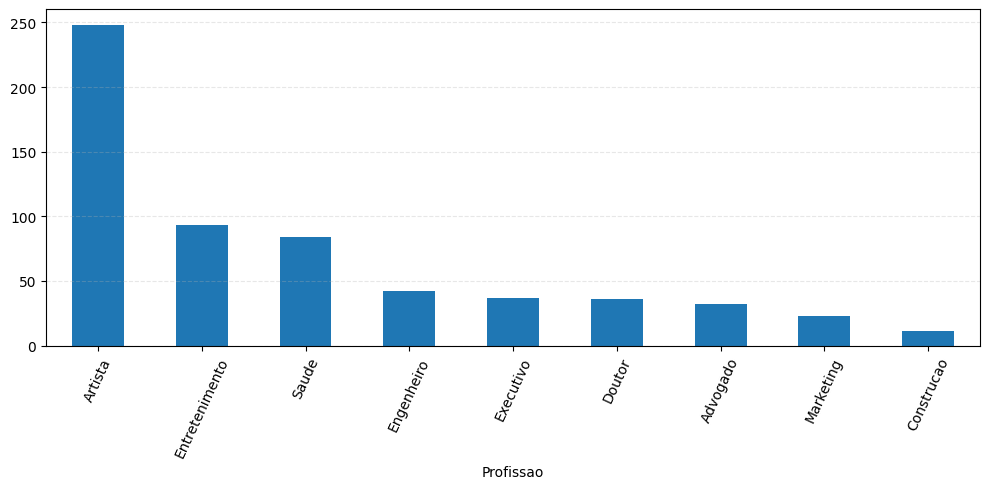

In [11]:
# GRÁFICO COM AS PROFISSÕES DOS CLIENTES IDEAIS

profissoes = funcoes.obter_profissoes_ci(df=clientes_ideais)

funcoes.criar_grafico_barras(dados=profissoes,
                             titulo='Top Profissões com Nota 70+',
                             xlabel='Profissões',
                             ylabel='Quantidade de Clientes',
                             rotacao=65)


#### PROFISSÕES LIGADAS A ARTISTAS SEGUINDO DE ENTRETENIMENTO SÃO PREDOMINANTES

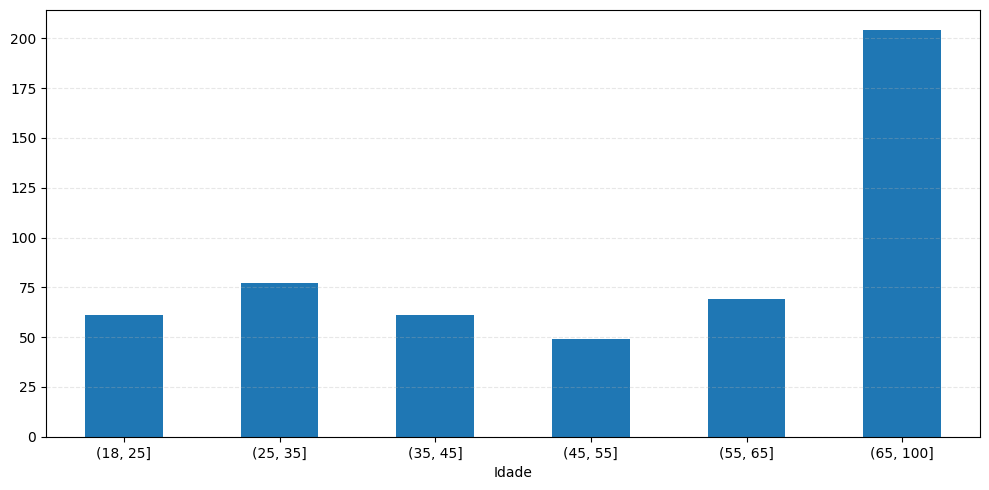

In [12]:
# GRÁFICO COM A FAIXA ETÁRIA DOS CLIENTES IDEAIS

faixa_idade = funcoes.criar_faixa_etaria(df=clientes_ideais)


funcoes.criar_grafico_barras(dados=faixa_idade,
                             titulo='Distribuição de idade - Clientes com Nota 70+',
                             xlabel='Faixa Etária',
                             ylabel='Quantidade de Clientes')

#### CLIENTES COM SCORE ACIMA DE 70 CONCENTRAM-SE MAJORITARIAMENTE ENTRE 65+ ANOS 

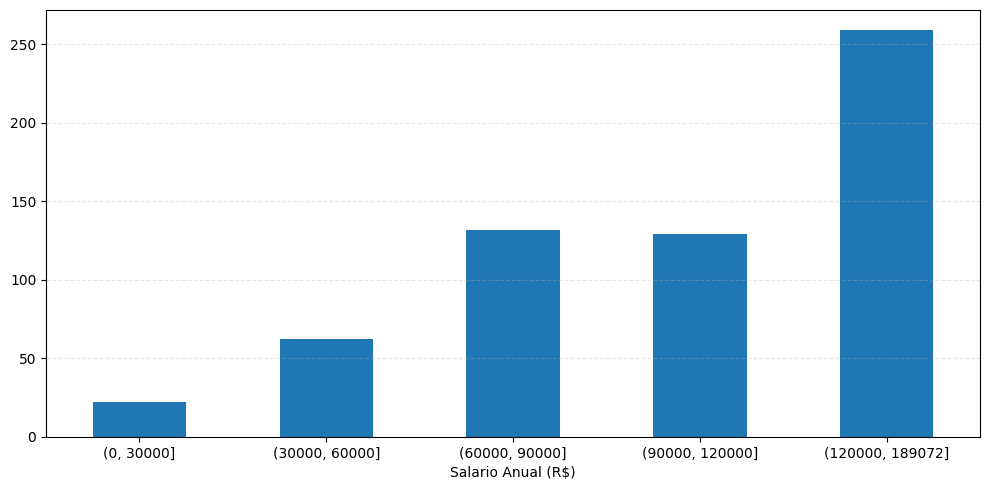

In [14]:
# FAIXA DE RENDA 

# faixa_salario = pd.cut(clientes_ideais['Salario Anual (R$)'],
#                         bins=[0,30000,60000,90000,120000,
#                         clientes_ideais['Salario Anual (R$)'].max()]).value_counts().sort_index()

faixa_salario = funcoes.criar_faixa_salarial(df=clientes_ideais)


# faixa_salario = funcoes.criar_faixa_salarial(df=clientes_ideais)

funcoes.criar_grafico_barras(dados=faixa_salario,
                             titulo='Distribuição Salarial - Clientes Ideais',
                             xlabel='Faixa Salarial',
                             ylabel='Quantidade de Clientes')

#### A MAIOR PARTE POSSUI RENDA ANUAL ACIMA DE 120 MIL+ 

### FINALIZAÇÃO DO PROJETO

In [16]:
filtro_profissao = clientes_ideais['Profissao'].str.contains('Artista|Entretenimento',
                                                                     case=False,
                                                                     na=False)


clientes_ideais = clientes_ideais[(clientes_ideais['Idade'] >= 65) &
                                  (clientes_ideais['Salario Anual (R$)']>= 120000) &
                                  (filtro_profissao)]

In [17]:
clientes_ideais.shape
clientes_ideais[['Idade','Salario Anual (R$)','Profissao','Nota (1-100)']].describe()
clientes_ideais['Profissao'].value_counts()

Profissao
Artista           30
Entretenimento    20
Name: count, dtype: int64

In [18]:
display(clientes_ideais)

,ClienteID,Origem,Idade,Salario Anual (R$),Nota (1-100),Profissao,Experiencia Trabalho,Tamanho Familia
286,287,Promocao,85,140000,92,Entretenimento,1,1
300,301,Normal,85,153787,100,Entretenimento,3,3
340,341,Promocao,84,173185,100,Artista,3,1
341,342,Normal,75,142034,94,Entretenimento,1,4
349,350,Promocao,88,166107,100,Artista,13,4
378,379,Promocao,82,180288,85,Artista,2,2
384,385,Promocao,79,143560,91,Artista,1,3
385,386,Normal,83,131574,100,Artista,1,2
394,395,Promocao,75,151696,97,Artista,15,1
462,463,Normal,93,120597,100,Artista,2,4
